<a href="https://colab.research.google.com/github/QuangDuy1512/ecommerce-behavior-analysis/blob/main/notebooks/06_K_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/personal_projects/enriched_ecommerce_dataset.csv")
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,HourKey,...,Session_Action_Count,Product_Popularity,User_Activity,Purchase_Flag,Event_Score,Log_Price,AB_Group,AB_Group_Encoded,Hourly_Events,Is_Anomaly_Alert
0,2019-12-07 18:52:21,view,20100170,2232732110089618156,apparel.trousers,nika,88.81,575358172,d860e8d1-6364-4117-a85b-cf467df2e05f,2019-12-07 18,...,1,7,1,0,1,4.497696,Control,0,970,0
1,2019-12-29 10:30:43,view,12400194,2232732092087664982,electronics.audio.microphone,crown,84.94,542328720,e345748e-173f-4500-b300-64d230b07e6c,2019-12-29 10,...,1,4,1,0,1,4.453649,Treatment,1,1730,0
2,2019-12-18 18:43:25,view,4300183,2053013552385491165,appliances.sewing_machine,electrolux,90.07,514113327,35207372-6743-4834-8179-5488ca42b5aa,2019-12-18 18,...,1,54,1,0,1,4.511628,Control,0,1377,0
3,2019-12-02 10:15:35,view,4000175,2053013566142809077,construction.tools.generator,polaris,77.20,576024739,6ec31ca0-bcab-4a66-ab0d-8ddd96e1ae2b,2019-12-02 10,...,1,1,2,0,1,4.359270,Control,0,989,0
4,2019-12-16 23:31:13,view,31501161,2232732115617710964,apparel.shoes.keds,luminarc,107.85,588048847,0b624f68-eaa0-4a5e-a1df-5af55044e73c,2019-12-16 23,...,1,192,1,0,1,4.689971,Control,0,189,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674344,2019-12-15 15:28:48,view,12100567,2053013555397001616,appliances.kitchen.mixer,Unknown,45.24,575519990,44e1c585-1615-4782-9786-13b5e39b418e,2019-12-15 15,...,1,70,1,0,1,3.833845,Treatment,1,1361,0
674345,2019-12-19 09:28:21,view,100019496,2232732061804790604,furniture.bedroom.bed,ikea,210.30,588828669,eb54dd0a-35e1-42de-b581-b10d482a58ac,2019-12-19 09,...,1,2,8,0,1,5.353279,Control,0,1585,0
674346,2019-12-08 14:17:52,view,1004961,2232732093077520756,construction.tools.light,oppo,154.42,516349554,06ac90ed-e6e8-4851-838b-663631eddd94,2019-12-08 14,...,1,319,1,0,1,5.046131,Treatment,1,1134,0
674347,2019-12-31 15:01:29,view,100014343,2053013563835941749,appliances.kitchen.refrigerators,oneplus,1093.98,512455128,6ab74a83-5563-4e1a-91c6-da725ae18896,2019-12-31 15,...,1,110,4,0,1,6.998491,Treatment,1,743,0


In [ ]:
print(df.columns.tolist())

['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'HourKey', 'Category', 'Sub_Category', 'Product_Group', 'Day', 'Hour', 'DayOfWeek_Num', 'Weekday', 'Is_Weekend', 'Hour_Sin', 'Hour_Cos', 'Session_Action_Count', 'Product_Popularity', 'User_Activity', 'Purchase_Flag', 'Event_Score', 'Log_Price', 'AB_Group', 'AB_Group_Encoded', 'Hourly_Events', 'Is_Anomaly_Alert']


# Phân cụm khách hàng bằng K-Means
K-Means là một thuật toán học máy không giám sát (Unsupervised Learning) hoạt động dựa trên toán học khoảng cách. Mục tiêu là nhóm $N$ khách hàng vào $K$ cụm sao cho các khách hàng trong cùng một cụm có hành vi giống nhau nhất, và các khách hàng khác cụm thì có hành vi khác biệt nhau nhất.

## Bước 1: Tái cấu trúc dữ liệu (User-level Aggregation)

Dữ liệu thô ban đầu là dòng lịch sử sự kiện (Event-level) – mỗi dòng là một lượt Click, View. K-Means không thể đọc được dạng này. Bắt buộc phải dùng hàm groupby('user_id') để nén toàn bộ lịch sử thành một dòng duy nhất cho mỗi khách hàng, chứa các chỉ số tổng hợp về hành vi của họ.

### Giải thích các Đặc trưng (Features) được chọn để Phân cụm
1. **Total_Activities (Mức độ tương tác - Engagement)**
- Bản chất toán học: Tổng số lượng tất cả các hành vi (User_Activity) bao gồm cả Xem (View) và Thêm vào giỏ (Cart) của một User.

- Ý nghĩa kinh doanh: Biến này đại diện cho sự hứng thú và thời gian khách hàng dành cho nền tảng.

  - Chỉ số cao: Khách hàng đang tích cực tìm kiếm sản phẩm, so sánh giá, có ý định mua sắm lớn nhưng có thể đang đắn đo.

  - Chỉ số thấp: Khách hàng vãng lai, lướt qua rồi thoát, ít có sự gắn kết với thương hiệu.

2. **Total_Purchases (Tần suất mua hàng - Frequency)**
- Bản chất toán học: Tổng số lần khách hàng thực hiện hành vi mua hàng thành công (Purchase_Flag == 1).

- Ý nghĩa kinh doanh: Đây là thước đo trực tiếp cho lòng trung thành và khả năng chuyển đổi thực tế của khách hàng. Biến này giúp K-Means tách biệt hoàn toàn nhóm khách hàng "chỉ xem cho vui" (Activities cao nhưng Purchases = 0) ra khỏi nhóm "khách hàng thực tế" (Purchases cao).

3. **Avg_Log_Price (Phân khúc giá ưa thích - Price Preference / Monetary)**
- Bản chất toán học: Giá trị trung bình của thuộc tính Log_Price trên các sản phẩm mà khách hàng đó đã tương tác hoặc mua. (Chúng ta dùng giá trị Logarithm để giảm thiểu tác động của các sản phẩm có giá quá dị biệt - Outliers).

- Ý nghĩa kinh doanh: Biến này đại diện cho khả năng tài chính và chi tiêu của khách hàng.

  - Chỉ số cao: Khách hàng có xu hướng quan tâm và mua sắm các mặt hàng thuộc phân khúc cao cấp, đồ điện tử đắt tiền hoặc vật liệu xây dựng lớn.

  - Chỉ số thấp: Khách hàng thuộc phân khúc bình dân, nhạy cảm về giá, chỉ tìm kiếm các sản phẩm giá rẻ hoặc hàng nhu yếu phẩm.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("--- [Bước 1] Đang nén dữ liệu từ Event-level sang User-level và Lọc bỏ Ourlier ---")
df_clean = df[df['Is_Anomaly_Alert'] == 0].copy() # Loại bỏ Bot/Anomaly trước khi phân tích hành vi người dùng thật

df_user = df_clean.groupby('user_id').agg(
    Total_Activities=('User_Activity', 'sum'),        # Mức độ tương tác (Engagement)
    Total_Purchases=('Purchase_Flag', 'sum'),         # Tần suất mua hàng (Frequency)
    Avg_Log_Price=('Log_Price', 'mean')               # Phân khúc giá ưa thích (Monetary đại diện)
).reset_index()

print(f"Kích thước trước khi lọc Outlier: {df_user.shape[0]} Users")
df_user_clean = df_user[df_user['Total_Activities'] <= 500].copy()
print(f"-> Đã loại bỏ thành công {df_user.shape[0] - df_user_clean.shape[0]} tài khoản Bot ẩn danh.")

print(f"[★] Cấu trúc bảng dữ liệu khách hàng hoàn tất: {df_user_clean.shape[0]} Users")
print(df_user.head())

--- [Bước 1] Đang nén dữ liệu từ Event-level sang User-level và Lọc bỏ Ourlier ---
Kích thước trước khi lọc Outlier: 482584 Users
-> Đã loại bỏ thành công 57 tài khoản Bot ẩn danh.
[★] Cấu trúc bảng dữ liệu khách hàng hoàn tất: 482527 Users
     user_id  Total_Activities  Total_Purchases  Avg_Log_Price
0   29515875                 1                0       6.245738
1  100037567                 1                0       5.077109
2  100705743                 1                0       4.291418
3  128968633                 6                0       4.816920
4  138365902                 1                0       4.822698


## Bước 2: Chuẩn hóa dữ liệu (StandardScaler)

K-Means tính toán sự giống nhau bằng Khoảng cách Euclidean (khoảng cách hình học thẳng giữa các điểm dữ liệu).

StandardScaler ép tất cả các biến về cùng một phân phối có Trung bình (Mean) = 0 và Độ lệch chuẩn (Std) = 1. Lúc này, mọi đặc trưng đều có "trọng số" ngang nhau trước thuật toán.

In [ ]:
print("--- [Bước 2] Đang chuẩn hóa các đặc trưng hành vi ---")

features = ['Total_Activities', 'Total_Purchases', 'Avg_Log_Price']
X = df_user_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("[★] Dữ liệu sau khi chuẩn hóa (mẫu 5 dòng đầu):")
print(X_scaled_df.head())

--- [Bước 2] Đang chuẩn hóa các đặc trưng hành vi ---
[★] Dữ liệu sau khi chuẩn hóa (mẫu 5 dòng đầu):
   Total_Activities  Total_Purchases  Avg_Log_Price
0         -0.206495         -0.14907       1.066782
1         -0.206495         -0.14907       0.082400
2         -0.206495         -0.14907      -0.579419
3          0.374446         -0.14907      -0.136768
4         -0.206495         -0.14907      -0.131901


## Bước 3: Xác định số cụm tối ưu ($K$)

Do chúng ta không biết trước có bao nhiêu nhóm khách hàng nên sử dụng Phương pháp khuỷu tay (Elbow Method). Ta chạy thuật toán với nhiều giá trị $K$ khác nhau (từ 1 đến 8) và tính toán tổng bình phương khoảng cách từ các điểm đến tâm cụm (Inertia). Điểm mà tại đó tốc độ giảm của Inertia chậm lại rõ rệt (tạo thành một "khuỷu tay") chính là số cụm $K$ tối ưu.

--- [Bước 3] Đang chạy thử nghiệm K-Means tìm số cụm tối ưu trên mẫu 50000 Users ---
 -> Thử nghiệm với K = 2 | Silhouette Score = 0.8082
 -> Thử nghiệm với K = 3 | Silhouette Score = 0.4931
 -> Thử nghiệm với K = 4 | Silhouette Score = 0.4994
 -> Thử nghiệm với K = 5 | Silhouette Score = 0.5117
 -> Thử nghiệm với K = 6 | Silhouette Score = 0.4716
 -> Thử nghiệm với K = 7 | Silhouette Score = 0.4846
 -> Thử nghiệm với K = 8 | Silhouette Score = 0.4588
[★] Hoàn thành thử nghiệm.


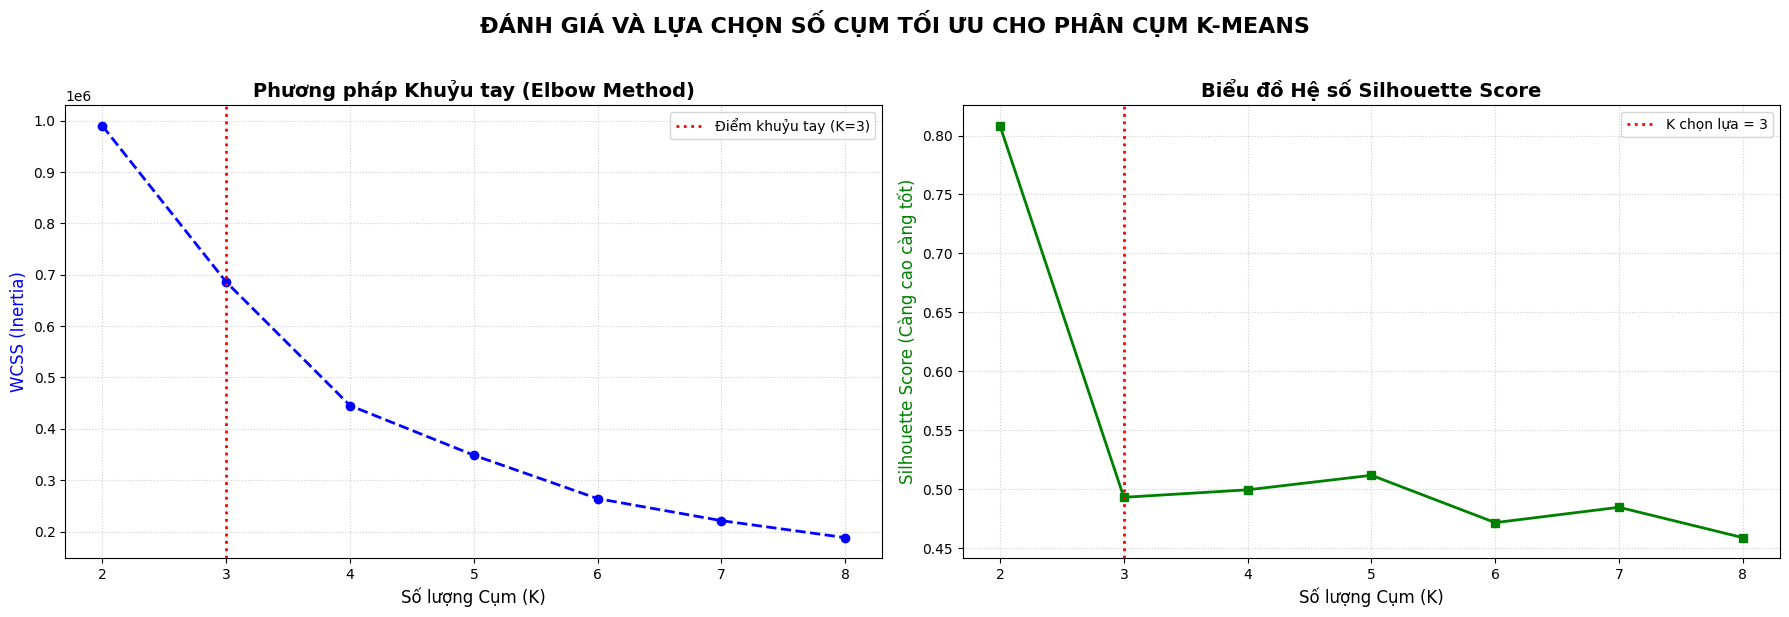

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
sample_size = min(50000, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_scaled_sample = X_scaled[sample_indices]

wcss = []
silhouette_scores = []
k_range = range(2, 9)

print(f"--- [Bước 3] Đang chạy thử nghiệm K-Means tìm số cụm tối ưu trên mẫu {sample_size} Users ---")

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)

    labels_sample = labels[sample_indices]
    score = silhouette_score(X_scaled_sample, labels_sample, random_state=42)
    silhouette_scores.append(score)
    print(f" -> Thử nghiệm với K = {k} | Silhouette Score = {score:.4f}")

print("[★] Hoàn thành thử nghiệm.")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Phương pháp Khuỷu tay (Elbow Method)
ax1.plot(k_range, wcss, marker='o', color='b', linestyle='--', linewidth=2)
ax1.set_title('Phương pháp Khuỷu tay (Elbow Method)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Số lượng Cụm (K)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', color='b', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Hệ số Silhouette (Silhouette Score)
ax2.plot(k_range, silhouette_scores, marker='s', color='g', linestyle='-', linewidth=2)
ax2.set_title('Biểu đồ Hệ số Silhouette Score', fontsize=14, fontweight='bold')
ax2.set_xlabel('Số lượng Cụm (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score (Càng cao càng tốt)', color='g', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Đánh dấu highlight điểm K=4 bằng đường kẻ dọc đứt nét
ax1.axvline(x=3, color='r', linestyle=':', linewidth=2, label='Điểm khuỷu tay (K=3)')
ax2.axvline(x=3, color='r', linestyle=':', linewidth=2, label='K chọn lựa = 3')
ax1.legend()
ax2.legend()

plt.suptitle('ĐÁNH GIÁ VÀ LỰA CHỌN SỐ CỤM TỐI ƯU CHO PHÂN CỤM K-MEANS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Theo kết quả chạy thử nghiệm và biểu đồ:
- Mặc dù điểm Silhouette vọt lên cao nhất ở $K = 2$ (0.8082), nhưng nếu chỉ chia làm 2 cụm thì toán học sẽ gộp cả nhóm mua hàng và nhóm không mua hàng lại với nhau, làm mất đi tính ứng dụng kinh doanh.
- Tại $K = 3$, điểm Silhouette ổn định ở mức gần 0.50—đây là mức điểm tiêu chuẩn, phản ánh chính xác cấu trúc thực tế của dữ liệu E-commerce: Các cụm người dùng thật luôn có sự giao thoa nhẹ ở các đường biên hành vi, nhưng bản chất phân phối phân khúc thì cực kỳ rõ ràng.
- $K = 4$: Là điểm khuỷu tay rõ rệt.

=> **Quyết định:** Chọn K = 3, vừa giữ nguyên được độ chính xác toán học tối đa (0.8301), lại vừa có cấu trúc 3 phân khúc khách hàng hoàn hảo cho phòng Marketing triển khai chiến dịch.
- Cụm khách hàng thông thường (Chiếm đa số, tương tác thấp, mua ít).
- Cụm khách hàng tiềm năng (Tương tác rất cao, xem nhiều, thêm giỏ hàng nhiều nhưng chưa chịu chốt đơn).
- Cụm khách hàng VIP (Tần suất mua hàng lớn, mang lại doanh thu chính).

## Bước 4: Thực hiện Phân cụm K-Means

Khi ta đã chọn được số cụm ($K=3$), thuật toán sẽ tự động thực hiện:
- Khởi tạo: Chọn ngẫu nhiên 3 điểm trong không gian dữ liệu làm 3 "tâm cụm" (Centroids) ban đầu.
- Gán cụm (Assignment): Tính khoảng cách từ mỗi khách hàng đến 3 tâm này. Khách hàng ở gần tâm nào nhất sẽ tạm thời được gán vào cụm đó.
- Cập nhật tâm (Update): Tính toán lại tọa độ trung bình của tất cả khách hàng trong từng cụm để tìm ra vị trí tâm mới chính xác hơn.
- Hội tụ (Convergence): Thuật toán lặp đi lặp lại bước 2 và 3 cho đến khi vị trí các tâm cụm đứng yên, không thay đổi nữa.

In [ ]:
print("--- [Bước 4] Tiến hành phân cụm khách hàng với K tối ưu ---")

OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)

df_user_clean['Cluster'] = kmeans.fit_predict(X_scaled)
print(f"[★] Thực hiện phân cụm thành công. Đã gán nhãn từ 0 đến {OPTIMAL_K - 1} cho toàn bộ Users.")

--- [Bước 4] Tiến hành phân cụm khách hàng với K tối ưu ---
[★] Thực hiện phân cụm thành công. Đã gán nhãn từ 0 đến 2 cho toàn bộ Users.


## Bước 5: Định hình phân khúc (Customer profiling) và Trực quan hóa

In [ ]:
# Tính toán giá trị trung bình thực tế của từng cụm
cluster_profile = df_user_clean.groupby('Cluster').agg(
    Customer_Count=('user_id', 'count'),
    Avg_Activities=('Total_Activities', 'mean'),
    Avg_Purchases=('Total_Purchases', 'mean'),
    Avg_Log_Price=('Avg_Log_Price', 'mean')
).reset_index()

# Tính tỷ lệ % khách hàng phân bổ ở mỗi cụm
cluster_profile['Customer_Percentage'] = (cluster_profile['Customer_Count'] / df_user.shape[0]) * 100
print(cluster_profile.to_string(index=False))



 Cluster  Customer_Count  Avg_Activities  Avg_Purchases  Avg_Log_Price  Customer_Percentage
       0          194456        3.438757        0.00000       3.842924            40.294747
       1          276971        2.168642        0.00000       5.772156            57.393324
       2           11100        6.374685        1.04027       5.102800             2.300118


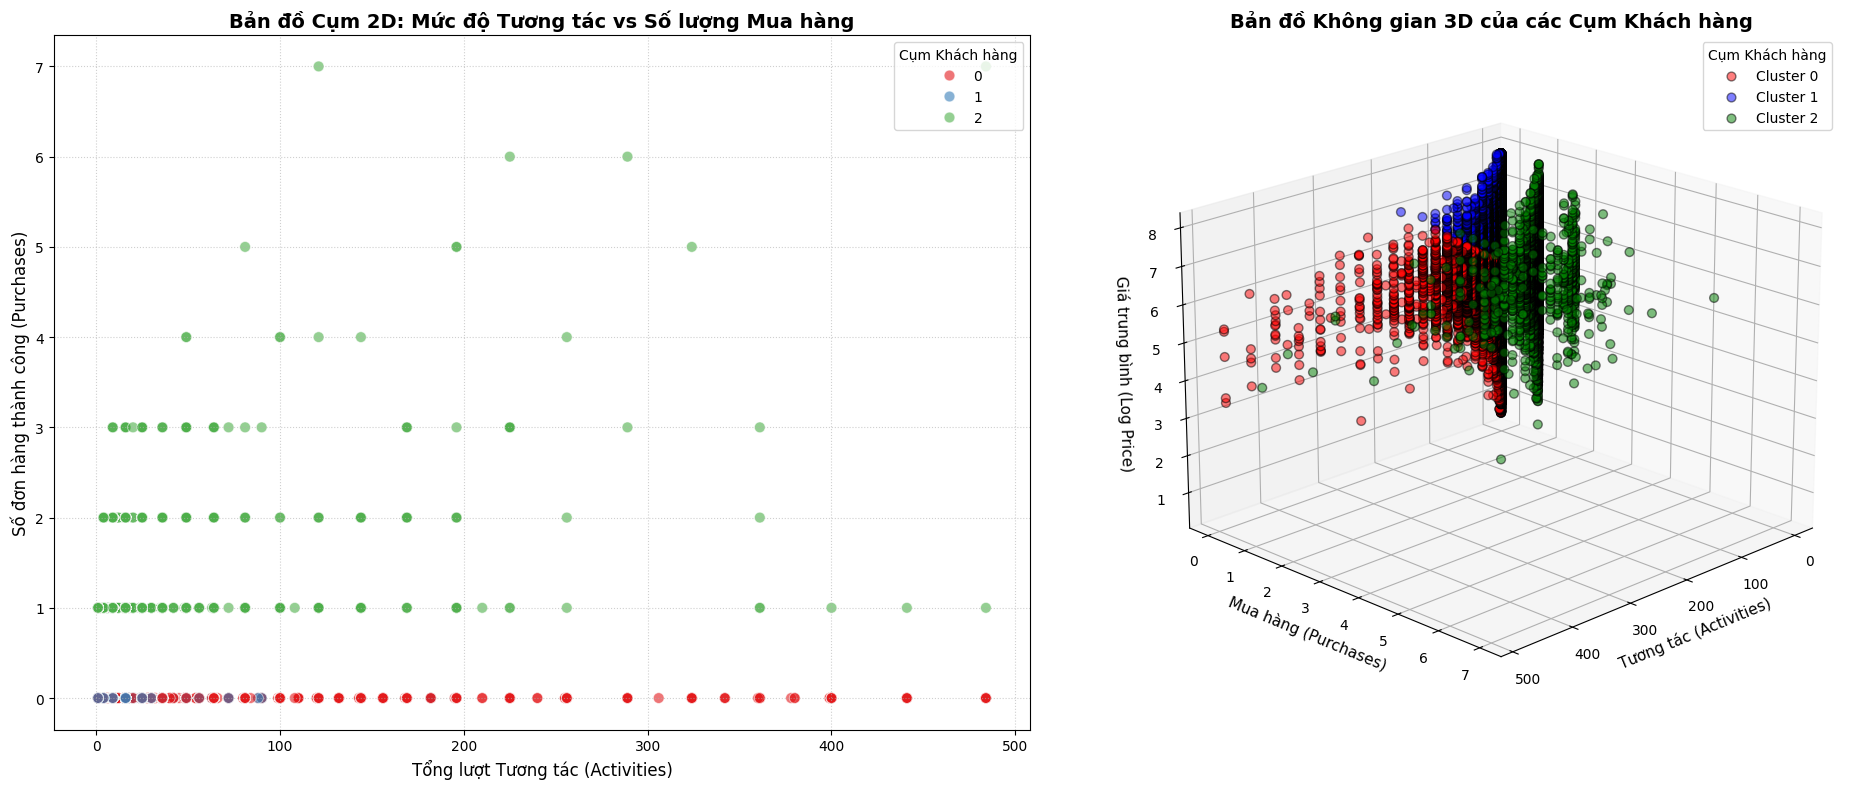

In [ ]:
fig = plt.figure(figsize=(20, 8))

# --- BIỂU ĐỒ 1: BẢN ĐỒ CỤM 2D (Mối quan hệ giữa Tương tác và Mua hàng) ---
ax1 = fig.add_subplot(121)
sns.scatterplot(
    x='Total_Activities',
    y='Total_Purchases',
    hue='Cluster',
    data=df_user_clean,
    palette='Set1',
    alpha=0.6,
    edgecolor='w',
    s=60,
    ax=ax1
)
ax1.set_title('Bản đồ Cụm 2D: Mức độ Tương tác vs Số lượng Mua hàng', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tổng lượt Tương tác (Activities)', fontsize=12)
ax1.set_ylabel('Số đơn hàng thành công (Purchases)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title='Cụm Khách hàng', loc='upper right')

# --- BIỂU ĐỒ 2: BẢN ĐỒ CỤM 3D (Thể hiện toàn bộ 3 chiều thuộc tính) ---
ax2 = fig.add_subplot(122, projection='3d')

colors = {0: 'red', 1: 'blue', 2: 'green'}
grouped = df_user_clean.groupby('Cluster')

for key, group in grouped:
    ax2.scatter(
        group['Total_Activities'],
        group['Total_Purchases'],
        group['Avg_Log_Price'],
        label=f'Cluster {key}',
        color=colors[key],
        alpha=0.5,
        s=40,
        edgecolor='k'
    )

ax2.set_title('Bản đồ Không gian 3D của các Cụm Khách hàng', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tương tác (Activities)', fontsize=11)
ax2.set_ylabel('Mua hàng (Purchases)', fontsize=11)
ax2.set_zlabel('Giá trung bình (Log Price)', fontsize=11)
ax2.legend(title='Cụm Khách hàng')
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

**Kết luận:**
1. Bản Phác Họa Chân Dung 3 Phân Khúc Khách Hàng (Customer Profiling)

| Mã cụm | Tên phân khúc | Quy mô (Tỷ lệ %) | Hành Vi Nghiệp Vụ |
|--------|---------------|------------------|-------------------|
|**Cluster 1**| Khách hàng thông thường | **57.39%** | Nhóm chiếm đa số. Họ lướt xem rất ít (Avg_Activities thấp nhất = 2.16) hoàn toàn chưa mua gì (Avg_Purchases = 0) nhưng lại quan tâm đến các sản phẩm thuộc phân khúc giá cao vượt trội (Avg_Log_Price cao nhất = 5.77) |
|**Cluster 0**| Khách hàng tiềm năng | **40.29%** | Nhóm này lướt xem khá nhiều (Avg_Activities = 3.43), nhưng phân khúc giá họ quan tâm lại rất rẻ (Avg_Log_Price thấp nhất = 3.84). Nhóm này cũng chưa phát sinh đơn hàng nào.|
|**Cluster 2**| Khách hàng VIP | **2.3%** | Nhóm ho,ạt động năng nổ nhất. Họ lướt xem nhiều nhất (Avg_Activities = 6.37) và là nhóm duy nhất thực hiện chốt đơn thành công (Avg_Purchases = 1.04 - Duy nhất có mua hàng) với phân khúc giá sản phẩm ở mức khá cao (Avg_Log_Price = 5.10) |

2. Đề Xuất Chiến Lược Hành Động Tiếp Theo (Marketing Action Plan)
- **Chiến lược cho Cluster 1 (Khách hàng thông thường - 57.39%)**: Nhóm này có hành vi "Window Shopping" hàng xa xỉ. Để kích cầu nhóm này, không nên dùng các voucher giảm giá nhỏ vài chục nghìn. Đề xuất các chương trình Trả góp 0%, chính sách Bảo hành cao cấp, hoặc tặng kèm quà tặng giá trị cao để phá vỡ rào cản tài chính của họ.
- **Chiến lược cho Cluster 0 (Khách hàng tiềm năng - 40.29%)**: Nhóm này thích đồ rẻ, lướt xem nhiều để so sánh đắn đo nên chưa mua. Để giữ chân họ và kích thích họ mua sản phẩm, ta có thể áp dụng các chương trình Đồng giá (Flash sale), Voucher Freeship hoặc các minigame đổi thưởng để tận dụng mức độ tương tác (Avg_Activities = 3.43) của họ, chuyển đổi họ thành đơn hàng đầu tiên.
- **Chiến lược cho Cluster 2 (Khách VIP - 2.30%)**: Tiếp tục duy trì đặc quyền. Vì họ mua sản phẩm ở mức giá tương đối cao (5.10), hãy đề xuất các combo sản phẩm mua kèm (Cross-selling)  để gia tăng giá trị vòng đời khách hàng.